In [3]:
import os, logging
os.environ["CODECARBON_LOG_LEVEL"] = "critical"   # silence CodeCarbon
# extra belt-and-suspenders:
logging.getLogger("codecarbon").setLevel(logging.CRITICAL)
logging.getLogger("codecarbon").propagate = False

In [4]:
import sys, subprocess
pkgs = ["mlflow","feast","codecarbon","scikit-learn","pandas","numpy","matplotlib","pyarrow","pyyaml"]
subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + pkgs, check=True)

from pathlib import Path
assert Path("athletes.csv").exists(), "athletes.csv not found next to this notebook."
print(" Packages installed, CSV present.")

 Packages installed, CSV present.


In [5]:
from pathlib import Path

Path("feature_repo").mkdir(exist_ok=True)
Path("data_work").mkdir(exist_ok=True)

# feature_store.yaml
Path("feature_repo/feature_store.yaml").write_text("""\
project: athletes_local
registry: registry.db
provider: local
online_store:
  type: sqlite
  path: online_store.db
offline_store:
  type: file
""")

# feature_defs.py
Path("feature_repo/feature_defs.py").write_text("""\
from datetime import timedelta
from feast import Entity, FeatureView, Field, FileSource
from feast.types import Float32, Int64, UnixTimestamp

v1_source = FileSource(path="../data_work/v1.parquet", timestamp_field="event_ts")
v2_source = FileSource(path="../data_work/v2.parquet", timestamp_field="event_ts")

athlete = Entity(name="row_id", join_keys=["row_id"])

athletes_v1 = FeatureView(
    name="athletes_v1",
    entities=[athlete],
    ttl=timedelta(days=3650),
    schema=[
        Field(name="feat_num_1", dtype=Float32),
        Field(name="feat_num_2", dtype=Float32),
        Field(name="event_ts", dtype=UnixTimestamp),
        Field(name="row_id", dtype=Int64),
    ],
    source=v1_source,
)

athletes_v2 = FeatureView(
    name="athletes_v2",
    entities=[athlete],
    ttl=timedelta(days=3650),
    schema=[
        Field(name="feat_num_1", dtype=Float32),
        Field(name="feat_num_2", dtype=Float32),
        Field(name="feat_num_1_x_2", dtype=Float32),
        Field(name="feat_num_1_sq", dtype=Float32),
        Field(name="event_ts", dtype=UnixTimestamp),
        Field(name="row_id", dtype=Int64),
    ],
    source=v2_source,
)
""")
print(" Feast repo files created.")

 Feast repo files created.


In [6]:
import pandas as pd, numpy as np
from pathlib import Path

df = pd.read_csv("athletes.csv").copy()

# join key + event timestamp
if "row_id" not in df.columns:
    df.insert(0, "row_id", np.arange(len(df), dtype=int))
base_ts = pd.Timestamp.utcnow().floor("s")
df["event_ts"] = base_ts - pd.to_timedelta(np.arange(len(df))[::-1], unit="s")

# pick numeric target (last numeric col); change if you have a specific target
num_cols = [c for c in df.columns if c not in ["row_id"] and pd.api.types.is_numeric_dtype(df[c])]
assert len(num_cols) >= 1, "Need at least one numeric column."
target = num_cols[-1]

feat_base = [c for c in num_cols if c not in ["row_id","event_ts",target]]
assert len(feat_base) >= 1, "Need at least one numeric feature besides target."
feat_keep = feat_base[:2] if len(feat_base) >= 2 else feat_base

rename_map = {c: f"feat_num_{i+1}" for i,c in enumerate(feat_keep)}
v1 = df[["row_id","event_ts"] + feat_keep].rename(columns=rename_map).copy()

v2 = v1.copy()
if "feat_num_1" in v2.columns and "feat_num_2" in v2.columns:
    v2["feat_num_1_x_2"] = v2["feat_num_1"] * v2["feat_num_2"]
if "feat_num_1" in v2.columns:
    v2["feat_num_1_sq"] = v2["feat_num_1"] ** 2

Path("data_work/v1.parquet").parent.mkdir(exist_ok=True)
v1.to_parquet("data_work/v1.parquet", index=False)
v2.to_parquet("data_work/v2.parquet", index=False)

entity_df = df[["row_id","event_ts",target]].rename(columns={target:"label"})
entity_df.to_parquet("data_work/entity_df.parquet", index=False)
print(" v1/v2 features + entity_df written to data_work/")

 v1/v2 features + entity_df written to data_work/


In [7]:
import subprocess
subprocess.run(["feast","apply"], cwd="feature_repo", check=True)
print("feast apply complete.")

/home/jupyter/ML_ops/feature_repo/feature_defs.py:8: DeprecationWarning: Entity value_type will be mandatory in the next release. Please specify a value_type for entity 'row_id'.
  athlete = Entity(name="row_id", join_keys=["row_id"])


No project found in the repository. Using project name athletes_local defined in feature_store.yaml
Applying changes for project athletes_local
Created project athletes_local
Created entity row_id
Created feature view athletes_v2
Created feature view athletes_v1

Created sqlite table athletes_local_athletes_v1
Created sqlite table athletes_local_athletes_v2

feast apply complete.


2025/10/25 17:34:27 INFO mlflow.tracking.fluent: Experiment with name 'athletes_gcp' does not exist. Creating a new experiment.



=== Run 1/4: v1-200-6 ===
Using event_ts as the event timestamp. To specify a column explicitly, please name it event_timestamp.
Shapes: X=(45759, 3), y=(45759,)
RMSE=22447941.8095  R2=-0.0001


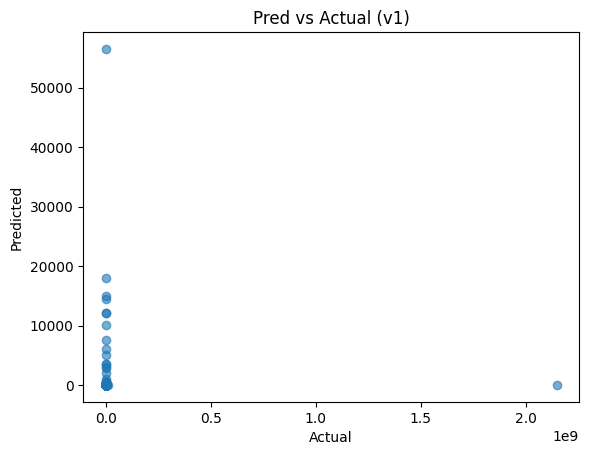

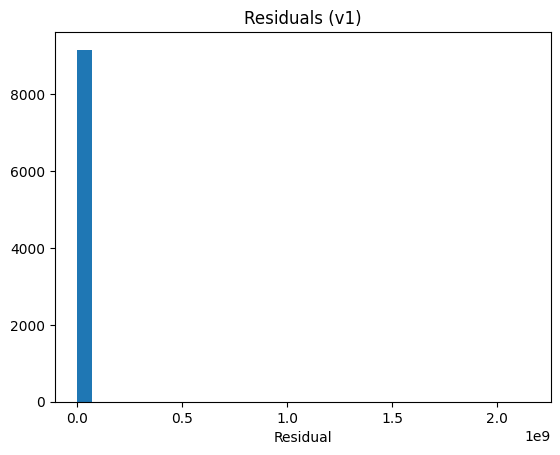

,feature,importance
1,feat_num_1,0.785172
0,row_id,0.213662
2,feat_num_2,0.001165


Emissions kgCO2: 0.000017

=== Run 2/4: v1-600-12 ===
Using event_ts as the event timestamp. To specify a column explicitly, please name it event_timestamp.
Shapes: X=(45759, 3), y=(45759,)
RMSE=22447939.0803  R2=-0.0001


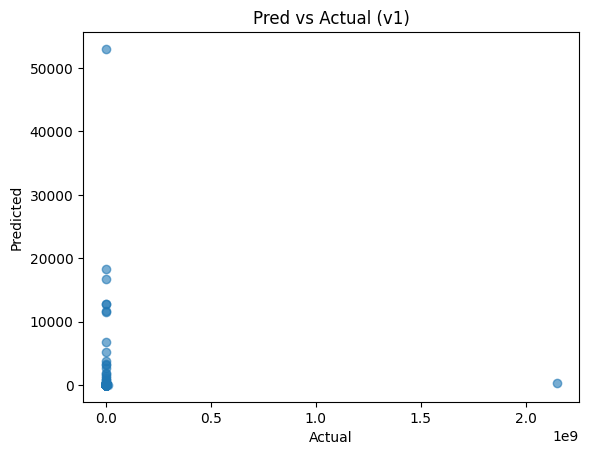

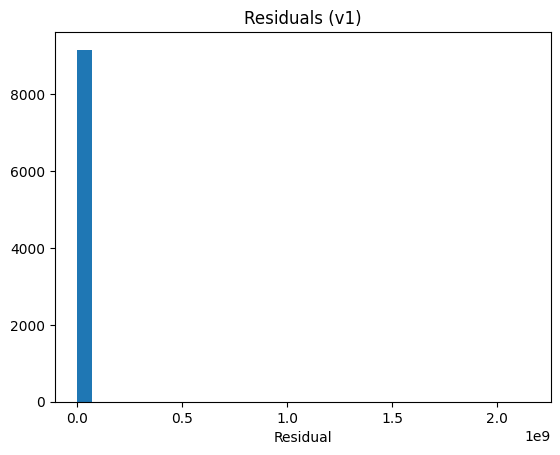

,feature,importance
1,feat_num_1,0.777626
0,row_id,0.218411
2,feat_num_2,0.003963


Emissions kgCO2: 0.000077

=== Run 3/4: v2-200-6 ===
Using event_ts as the event timestamp. To specify a column explicitly, please name it event_timestamp.
Shapes: X=(45759, 5), y=(45759,)
RMSE=22447941.8162  R2=-0.0001


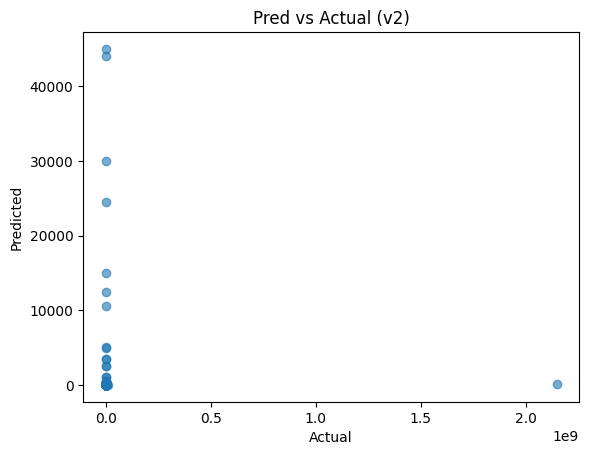

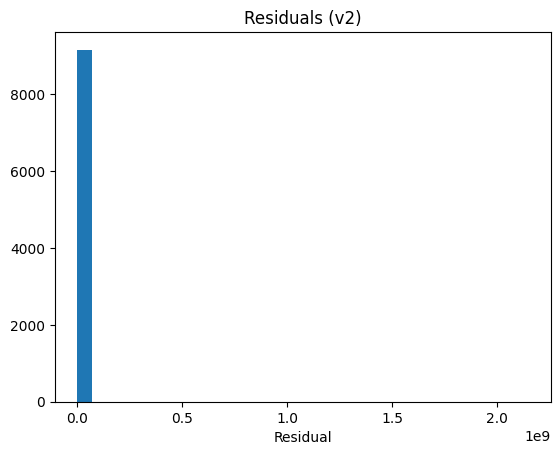

,feature,importance
3,feat_num_1_x_2,0.552969
0,row_id,0.174535
4,feat_num_1_sq,0.136690
1,feat_num_1,0.134646
2,feat_num_2,0.001160


Emissions kgCO2: 0.000030

=== Run 4/4: v2-600-12 ===
Using event_ts as the event timestamp. To specify a column explicitly, please name it event_timestamp.
Shapes: X=(45759, 5), y=(45759,)
RMSE=22447939.2408  R2=-0.0001


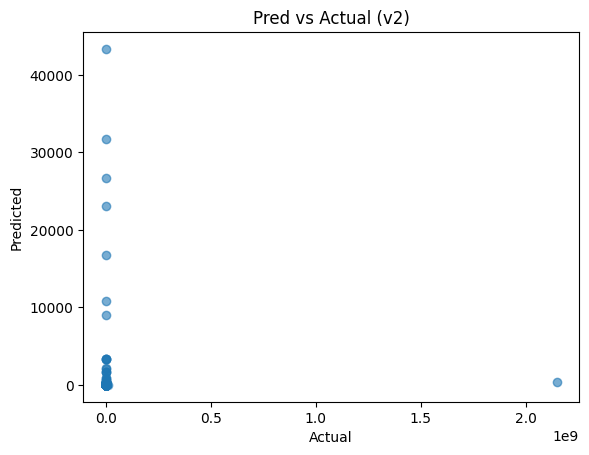

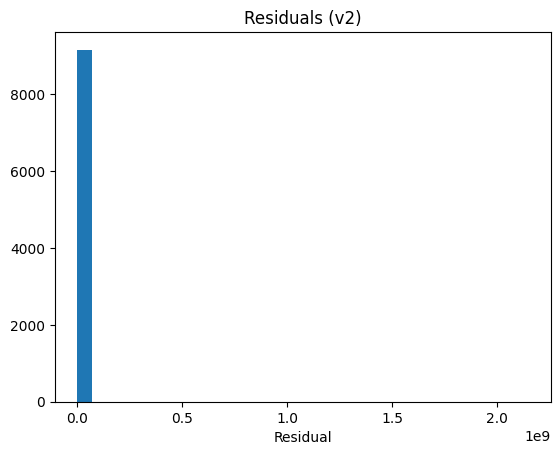

,feature,importance
3,feat_num_1_x_2,0.568292
0,row_id,0.172396
4,feat_num_1_sq,0.127290
1,feat_num_1,0.127149
2,feat_num_2,0.004873


Emissions kgCO2: 0.000140


,version,n_estimators,max_depth,random_state,rmse,r2
0,v1,200,6,42,2.244794e+07,-0.00011
1,v1,600,12,42,2.244794e+07,-0.00011
2,v2,200,6,42,2.244794e+07,-0.00011
3,v2,600,12,42,2.244794e+07,-0.00011


In [8]:
# 

import os
os.environ["CODECARBON_LOG_LEVEL"] = "critical"   # quiet CodeCarbon logs (optional)
# os.environ["CODECARBON_CPU_POWER_MAX"] = "15"   # optional: stabilize VM power estimate
import numpy as np  # make sure this import exists
import pandas as pd
from pathlib import Path
from feast import FeatureStore
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import mlflow
from codecarbon import EmissionsTracker


FEATURES = {
    "v1": ["athletes_v1:feat_num_1", "athletes_v1:feat_num_2"],
    "v2": ["athletes_v2:feat_num_1", "athletes_v2:feat_num_2", "athletes_v2:feat_num_1_x_2", "athletes_v2:feat_num_1_sq"],
}

# 2 HP sets for the SAME algorithm
HPS = [
    {"n_estimators": 200, "max_depth": 6, "random_state": 42},
    {"n_estimators": 600, "max_depth": 12, "random_state": 42},
]

def get_trainset(store: FeatureStore, feature_refs: list[str]) -> tuple[pd.DataFrame, pd.Series]:
    """
    Retrieve historical features with Feast and return clean X, y.
    This drops Feast metadata columns and any rows with NaNs in X or y.
    """
    entity_df = pd.read_parquet("data_work/entity_df.parquet")
    df = store.get_historical_features(
        entity_df=entity_df[["row_id", "event_ts", "label"]],
        features=feature_refs
    ).to_df()

    # separate label and features
    y = df["label"]
    X = df.drop(columns=["label", "event_ts"], errors="ignore")

  
    drop_cols = [c for c in X.columns if c.endswith("__entity__") or c.endswith("__event_ts__")]
    if drop_cols:
        X = X.drop(columns=drop_cols, errors="ignore")

    # keep only numeric feature columns
    feat_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
    X = X[feat_cols]

    clean = pd.concat([X, y.rename("label")], axis=1).dropna(axis=0, how="any")
    y_clean = clean["label"].astype(float)
    X_clean = clean.drop(columns=["label"])

    if X_clean.empty or y_clean.empty:
        raise ValueError("After cleaning, training set is empty. Check your target/feature NaNs.")

    return X_clean, y_clean

# init Feast + MLflow
store = FeatureStore(repo_path="feature_repo")
mlflow.set_experiment("athletes_gcp")

results = []
run_idx = 0

for ver, refs in FEATURES.items():
    for hp in HPS:
        run_idx += 1
        run_name = f"{ver}-{hp['n_estimators']}-{hp['max_depth']}"
        print(f"\n=== Run {run_idx}/4: {run_name} ===")

        with mlflow.start_run(run_name=run_name):
            mlflow.log_params({"feature_version": ver, **hp, "algorithm": "RandomForestRegressor"})

            tracker = EmissionsTracker(project_name="athletes_gcp", measure_power_secs=3, save_to_file=False)
            try:
                tracker.start()

                # ----- Data -----
                X, y = get_trainset(store, refs)
                print(f"Shapes: X={X.shape}, y={y.shape}")
                feat_cols = X.columns.tolist()

                # ----- Pipeline -----
                pipe = Pipeline([
                    ("pre", ColumnTransformer([("num", StandardScaler(), feat_cols)], remainder="drop")),
                    ("model", RandomForestRegressor(**hp)),
                ])

                Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
                pipe.fit(Xtr, ytr)
                yhat = pipe.predict(Xte)

                # ----- Metrics -----
              

                # ----- Metrics  -----
                mse = mean_squared_error(yte, yhat)
                rmse = float(np.sqrt(mse))            
                r2 = r2_score(yte, yhat)
                print(f"RMSE={rmse:.4f}  R2={r2:.4f}")
                mlflow.log_metrics({"rmse": rmse, "r2": r2})

                # ----- Plots -----
                fig1 = plt.figure()
                plt.scatter(yte, yhat, alpha=0.6)
                plt.xlabel("Actual"); plt.ylabel("Predicted"); plt.title(f"Pred vs Actual ({ver})")
                mlflow.log_figure(fig1, f"pred_vs_actual_{ver}.png")
                plt.show()

                fig2 = plt.figure()
                plt.hist(yte - yhat, bins=30)
                plt.xlabel("Residual"); plt.title(f"Residuals ({ver})")
                mlflow.log_figure(fig2, f"residuals_{ver}.png")
                plt.show()

                # ----- Feature importances -----
                rf = pipe.named_steps["model"]
                if hasattr(rf, "feature_importances_"):
                    fi = pd.DataFrame(
                        {"feature": feat_cols, "importance": rf.feature_importances_}
                    ).sort_values("importance", ascending=False)
                    display(fi)
                    p = Path(f"feature_importance_{ver}.csv")
                    fi.to_csv(p, index=False)
                    mlflow.log_artifact(str(p))

                results.append({"version": ver, **hp, "rmse": rmse, "r2": r2})

            finally:
                kg = tracker.stop() or 0.0
                mlflow.log_metric("codecarbon_kg_co2", kg)
                print(f"Emissions kgCO2: {kg:.6f}")


pd.DataFrame(results).sort_values(["version", "n_estimators", "max_depth"])

In [9]:
import pandas as pd

summary_df = pd.DataFrame(results).sort_values(["version","n_estimators","max_depth"]).reset_index(drop=True)
display(summary_df)
summary_df.to_csv("results_summary.csv", index=False)
print("Saved results_summary.csv")

,version,n_estimators,max_depth,random_state,rmse,r2
0,v1,200,6,42,2.244794e+07,-0.00011
1,v1,600,12,42,2.244794e+07,-0.00011
2,v2,200,6,42,2.244794e+07,-0.00011
3,v2,600,12,42,2.244794e+07,-0.00011


Saved results_summary.csv


In [10]:
import mlflow
import pandas as pd


runs = mlflow.search_runs(experiment_names=["athletes_gcp"])

# build summary with columns we need
df = runs[[
    "tags.mlflow.runName",
    "params.feature_version",
    "params.n_estimators",
    "params.max_depth",
    "metrics.rmse",
    "metrics.r2",
    "metrics.codecarbon_kg_co2",
    "end_time",
]].rename(columns={
    "tags.mlflow.runName": "run",
    "params.feature_version": "version",
    "params.n_estimators": "n_estimators",
    "params.max_depth": "max_depth",
    "metrics.rmse": "rmse",
    "metrics.r2": "r2",
    "metrics.codecarbon_kg_co2": "kg_co2",
})


for col in ["n_estimators", "max_depth"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df["n_estimators"] = df["n_estimators"].astype("Int64")
df["max_depth"]    = df["max_depth"].astype("Int64")


df_valid = df.dropna(subset=["rmse", "r2", "kg_co2"], how="any").copy()

## If the same run name appears multiple times, keep the latest (by end_time)
df_valid["end_time"] = pd.to_datetime(df_valid["end_time"], errors="coerce")
df_clean = (df_valid
            .sort_values(["run", "end_time"])
            .drop_duplicates(subset=["run"], keep="last"))


df_clean = df_clean.sort_values(["version","n_estimators","max_depth"]).reset_index(drop=True)

display(df_clean)
df_clean.to_csv("results_summary.csv", index=False)
print(" Cleaned and saved results_summary.csv")

,run,version,n_estimators,max_depth,rmse,r2,kg_co2,end_time
0,v1-200-6,v1,200,6,2.244794e+07,-0.00011,0.000017,2025-10-25 17:34:43.628000+00:00
1,v1-600-12,v1,600,12,2.244794e+07,-0.00011,0.000077,2025-10-25 17:35:49.979000+00:00
2,v2-200-6,v2,200,6,2.244794e+07,-0.00011,0.000030,2025-10-25 17:36:15.961000+00:00
3,v2-600-12,v2,600,12,2.244794e+07,-0.00011,0.000140,2025-10-25 17:38:13.892000+00:00


 Cleaned and saved results_summary.csv


In [11]:
# Re-run *just the training* once per config and log the fitted pipeline as an MLflow model.

from feast import FeatureStore
import mlflow, pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

store = FeatureStore(repo_path="feature_repo")

def load_xy(feature_refs):
    entity_df = pd.read_parquet("data_work/entity_df.parquet")
    df = store.get_historical_features(entity_df=entity_df[["row_id","event_ts","label"]],
                                       features=feature_refs).to_df()
    y = df["label"].astype(float)
    X = df.drop(columns=["label","event_ts"], errors="ignore")
    X = X.drop(columns=[c for c in X.columns if c.endswith("__entity__") or c.endswith("__event_ts__")], errors="ignore")
    X = X.select_dtypes(include="number").drop(columns=["row_id"], errors="ignore")  # drop id (optional)
    clean = pd.concat([X, y.rename("label")], axis=1).dropna()
    y = clean["label"].values; X = clean.drop(columns=["label"])
    return X, y

CONFIGS = [
    ("v1", ["athletes_v1:feat_num_1","athletes_v1:feat_num_2"], {"n_estimators":200,"max_depth":6,"random_state":42}),
    ("v1", ["athletes_v1:feat_num_1","athletes_v1:feat_num_2"], {"n_estimators":600,"max_depth":12,"random_state":42}),
    ("v2", ["athletes_v2:feat_num_1","athletes_v2:feat_num_2","athletes_v2:feat_num_1_x_2","athletes_v2:feat_num_1_sq"], {"n_estimators":200,"max_depth":6,"random_state":42}),
    ("v2", ["athletes_v2:feat_num_1","athletes_v2:feat_num_2","athletes_v2:feat_num_1_x_2","athletes_v2:feat_num_1_sq"], {"n_estimators":600,"max_depth":12,"random_state":42}),
]

mlflow.set_experiment("athletes_gcp")
for ver, refs, hp in CONFIGS:
    with mlflow.start_run(run_name=f"{ver}-{hp['n_estimators']}-{hp['max_depth']}-model"):
        mlflow.log_params({"feature_version": ver, **hp, "algorithm":"RandomForestRegressor"})
        X,y = load_xy(refs)
        feat_cols = list(X.columns)
        pipe = Pipeline([
            ("pre", ColumnTransformer([("num", StandardScaler(), feat_cols)], remainder="drop")),
            ("model", RandomForestRegressor(**hp))
        ])
        Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=0.2,random_state=42)
        pipe.fit(Xtr,ytr)
        # log the fitted pipeline as an artifact/model
        import mlflow.sklearn
        mlflow.sklearn.log_model(pipe, artifact_path="model")
        print(f"Logged model for {ver} {hp}")

Using event_ts as the event timestamp. To specify a column explicitly, please name it event_timestamp.


2025/10/25 17:38:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/25 17:38:25 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Logged model for v1 {'n_estimators': 200, 'max_depth': 6, 'random_state': 42}
Using event_ts as the event timestamp. To specify a column explicitly, please name it event_timestamp.


2025/10/25 17:39:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/25 17:39:04 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Logged model for v1 {'n_estimators': 600, 'max_depth': 12, 'random_state': 42}
Using event_ts as the event timestamp. To specify a column explicitly, please name it event_timestamp.


2025/10/25 17:39:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/25 17:39:25 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Logged model for v2 {'n_estimators': 200, 'max_depth': 6, 'random_state': 42}
Using event_ts as the event timestamp. To specify a column explicitly, please name it event_timestamp.


2025/10/25 17:40:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/25 17:40:57 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Logged model for v2 {'n_estimators': 600, 'max_depth': 12, 'random_state': 42}


,run,version,n_estimators,max_depth,rmse,r2,kg_co2
0,v1-200-6,v1,200,6,2.244794e+07,-0.00011,0.000017
1,v1-600-12,v1,600,12,2.244794e+07,-0.00011,0.000077
2,v2-200-6,v2,200,6,2.244794e+07,-0.00011,0.000030
3,v2-600-12,v2,600,12,2.244794e+07,-0.00011,0.000140


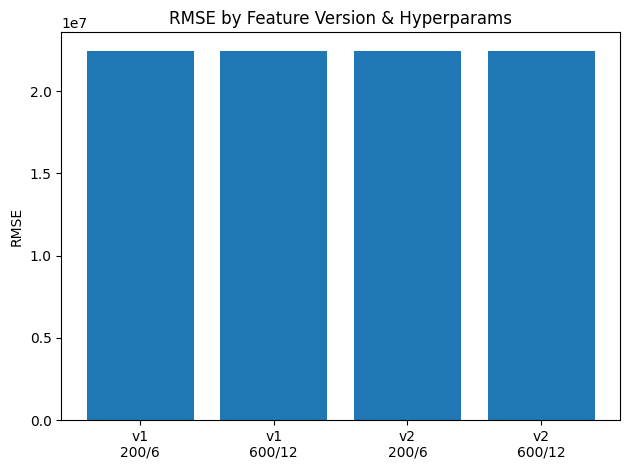

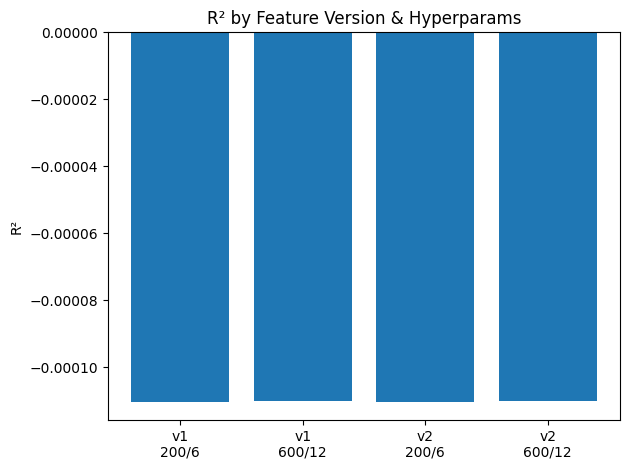

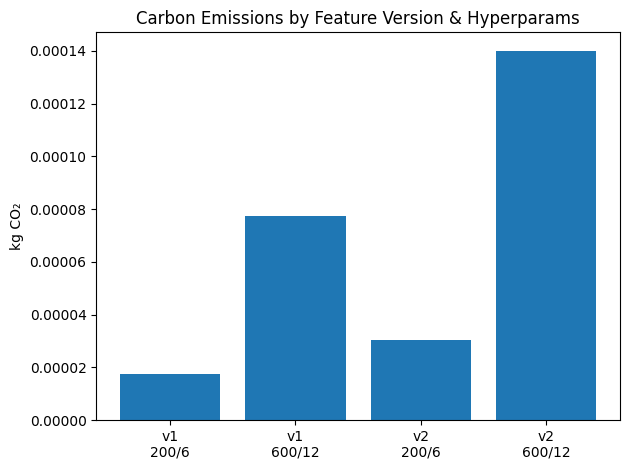

Saved: results_summary.csv, plot_rmse.png, plot_r2.png, plot_emissions.png


In [12]:
import mlflow, pandas as pd, matplotlib.pyplot as plt


runs = mlflow.search_runs(experiment_names=["athletes_gcp"])
summary_df = runs[["tags.mlflow.runName","params.feature_version","params.n_estimators","params.max_depth",
                   "metrics.rmse","metrics.r2","metrics.codecarbon_kg_co2"]].rename(columns={
    "tags.mlflow.runName":"run","params.feature_version":"version","params.n_estimators":"n_estimators",
    "params.max_depth":"max_depth","metrics.rmse":"rmse","metrics.r2":"r2","metrics.codecarbon_kg_co2":"kg_co2"})
summary_df["n_estimators"] = pd.to_numeric(summary_df["n_estimators"], errors="coerce").astype("Int64")
summary_df["max_depth"]    = pd.to_numeric(summary_df["max_depth"], errors="coerce").astype("Int64")
summary_df = summary_df.dropna(subset=["rmse","r2","kg_co2"]).sort_values(["version","n_estimators","max_depth"]).reset_index(drop=True)
summary_df.to_csv("results_summary.csv", index=False)
display(summary_df)

# Plots (bar charts)
xs = [f"{v}\n{int(ne)}/{int(md)}" for v,ne,md in zip(summary_df["version"], summary_df["n_estimators"], summary_df["max_depth"])]

plt.figure(); plt.bar(xs, summary_df["rmse"]); plt.ylabel("RMSE"); plt.title("RMSE by Feature Version & Hyperparams"); plt.tight_layout(); plt.savefig("plot_rmse.png", dpi=150); plt.show()
plt.figure(); plt.bar(xs, summary_df["r2"]);   plt.ylabel("R²");   plt.title("R² by Feature Version & Hyperparams");   plt.tight_layout(); plt.savefig("plot_r2.png", dpi=150);   plt.show()
plt.figure(); plt.bar(xs, summary_df["kg_co2"]); plt.ylabel("kg CO₂"); plt.title("Carbon Emissions by Feature Version & Hyperparams"); plt.tight_layout(); plt.savefig("plot_emissions.png", dpi=150); plt.show()

print("Saved: results_summary.csv, plot_rmse.png, plot_r2.png, plot_emissions.png")

In [13]:
### AI Acknowledgement

from pathlib import Path

ack_text = """# AI Assistance Acknowledgment

Portions of this project were developed with the assistance of **OpenAI ChatGPT-5**.

The tool was used to:
- Clarify Python syntax and resolve implementation errors during pipeline setup.
- Help structure the codebase and experiment workflow (feature store setup, training loop, logging).
- Provide guidance on integrating **Feast**, **MLflow**, and **CodeCarbon** on a GCP VM.
- Suggest visualization and comparison approaches (metrics and emissions plots).

Some parts of the code were drafted with ChatGPT-5’s assistance and then reviewed by me"""

Path("AI_ACKNOWLEDGEMENT.md").write_text(ack_text)
print(" AI_ACKNOWLEDGEMENT.md file created successfully.")

 AI_ACKNOWLEDGEMENT.md file created successfully.
